
# Tutorial 15 — Missing Values **Avanzado** (Manejo de datos faltantes)


**Objetivo:** comprender mecanismos de ausencia (MCAR/MAR/MNAR), aplicar estrategias **avanzadas** de imputación (condicional por grupos, **KNN Imputer**, **MICE**) y **evaluar el impacto** de la imputación (distribución y correlaciones), documentando y dejando trazabilidad.

**Qué lograrás al finalizar**
- Distinguir **MCAR**, **MAR** y **MNAR** y por qué importan metodológicamente.
- Aplicar **imputación condicional por grupos** y métodos multivariantes (KNN, MICE).
- Evaluar si una imputación **distorsiona** la distribución o las **relaciones** entre variables.
- Mantener **banderas de imputación** y buenas prácticas de documentación.




## 1) Material de estudio <a id="sec-1"></a>

### 1.1 ¿Por qué los datos faltantes son un desafío?
Los valores ausentes **reducen el tamaño efectivo de muestra**, pueden **introducir sesgos** (si la ausencia no es aleatoria) y **afectan modelos** (distribuciones y relaciones pueden cambiar tras imputar). Por eso, no es solo “rellenar espacios”: es una **decisión metodológica** que impacta la validez del análisis.

### 1.2 Mecanismos de ausencia (MCAR, MAR, MNAR)
- **MCAR** (*Missing Completely At Random*): la ausencia **no** depende de ninguna variable (observada o no). En general, eliminar o imputar **no introduce sesgo**.
- **MAR** (*Missing At Random*): la ausencia **sí** se explica por **otras variables observadas** (no por el propio valor faltante). Podemos usar dichas variables auxiliares para imputar mejor.
- **MNAR** (*Missing Not At Random*): la ausencia **depende del propio valor ausente**. Es el caso más difícil; suele requerir métodos avanzados y reconocer **limitaciones** de inferencia.

**Regla práctica:** antes de imputar, pregunta **por qué** faltan y explora **patrones** de ausencia (por grupos, rangos, categorías).

### 1.3 Estrategias avanzadas
1) **Imputación condicional por grupos**: imputar con estadísticos por segmento (p. ej., mediana por **edad** o **nivel educativo**). Respeta heterogeneidad y reduce distorsión.  
2) **Modelos multivariantes** (regresión, *learners*): aprovechar relaciones entre variables para estimar el valor faltante.  
3) **KNN Imputer**: usa los **vecinos más cercanos** para estimar el valor ausente a partir de observaciones similares.  
4) **MICE** (*Multiple Imputation by Chained Equations*): realiza imputaciones **encadenadas** y, en su versión completa, múltiples imputaciones para **propagar incertidumbre**.

**Evaluación posterior:** compara distribución **antes vs. después** y revisa **correlaciones**; evita correlaciones **artificiales** o cambios drásticos de media/varianza. Mantén **banderas** que indiquen qué observaciones fueron imputadas.

### 1.4 Flujo sugerido (en 5 pasos)
1. **Cuantificar** el faltante (por columna y por grupo).  
2. **Hipotetizar** mecanismo (MCAR/MAR/MNAR) con evidencia exploratoria.  
3. **Elegir** estrategia (condicional por grupos, KNN, MICE).  
4. **Imputar** manteniendo **flags** de trazabilidad.  
5. **Evaluar** impacto (distribuciones, correlaciones, y —cuando aplique— desempeño de modelos).

---




## 2) Ejemplos <a id="sec-2"></a>

> **Notas previas**
> - Los ejemplos usan datos **sintéticos** para reproducibilidad y rapidez.
> - Mantén **banderas** (`_was_missing`) para trazabilidad.


In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.impute import KNNImputer, SimpleImputer
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
import warnings
warnings.filterwarnings("ignore")

rng = np.random.default_rng(0)


In [2]:
# --- Datos sintéticos ---
N = 1500

df = pd.DataFrame({
    "edad": rng.integers(18, 80, size=N),
    "ingreso": np.clip(rng.normal(30000, 12000, size=N), 5000, None),
    "imc": np.clip(rng.normal(27, 5, size=N), 15, 50),
    "presion": np.clip(rng.normal(120, 15, size=N), 80, 200),
    "educacion": rng.choice(["baja", "media", "alta"], size=N, p=[0.3, 0.5, 0.2])
})

# Inyectar mecanismos de ausencia: MCAR, MAR, MNAR
# MCAR en IMC (10% al azar)
mask_imc_mcar = rng.random(N) < 0.10
df.loc[mask_imc_mcar, "imc"] = np.nan

# MAR en INGRESO: más faltantes en personas jóvenes (<30)
mask_ingreso_mar = (df["edad"] < 30) & (rng.random(N) < 0.30)
df.loc[mask_ingreso_mar, "ingreso"] = np.nan

# MNAR en PRESION: faltantes cuando la propia presión es alta
mask_presion_mnar = (df["presion"] > 140) & (rng.random(N) < 0.40)
df.loc[mask_presion_mnar, "presion"] = np.nan

# MCAR leve en EDUCACION (5%)
mask_edu_mcar = rng.random(N) < 0.05
df.loc[mask_edu_mcar, "educacion"] = np.nan

def missing_report(dataframe):
    total = len(dataframe)
    rep = pd.DataFrame({
        "faltantes": dataframe.isna().sum(),
        "porcentaje": (dataframe.isna().mean()*100).round(2)
    })
    rep["completos"] = total - rep["faltantes"]
    return rep.sort_values("porcentaje", ascending=False)

missing_report(df)


,faltantes,porcentaje,completos
imc,137,9.13,1363
ingreso,86,5.73,1414
educacion,86,5.73,1414
presion,59,3.93,1441
edad,0,0.00,1500


In [3]:

# === A) Imputación condicional por grupos (mediana por grupo) ===
df_grp = df.copy()

# Banderas (trazabilidad)
for col in ["ingreso", "presion", "imc", "educacion"]:
    df_grp[f"{col}_was_missing"] = df_grp[col].isna().astype(int)

# 1) INGRESO por grupo de educación (mediana por categoría)
df_grp["ingreso_imp"] = df_grp.groupby("educacion")["ingreso"].transform(
    lambda s: s.fillna(s.median())
)

# 2) PRESION por grupos de edad (bins)
edad_bins = pd.IntervalIndex.from_tuples([(18, 30), (30, 50), (50, 80)], closed="right")
df_grp["edad_grp"] = pd.cut(df_grp["edad"], bins=[18, 30, 50, 80], right=True, include_lowest=True)
df_grp["presion_imp"] = df_grp.groupby("edad_grp")["presion"].transform(
    lambda s: s.fillna(s.median())
)

# 3) EDUCACION (categoría): usar la moda global como ejemplo simple
mode_edu = df_grp["educacion"].mode(dropna=True)
mode_edu = mode_edu.iloc[0] if len(mode_edu) else "desconocida"
df_grp["educacion_imp"] = df_grp["educacion"].fillna(mode_edu)

# 4) IMC por educación (mediana por categoría)
df_grp["imc_imp"] = df_grp.groupby("educacion_imp")["imc"].transform(
    lambda s: s.fillna(s.median())
)

missing_report(df_grp[["ingreso_imp","presion_imp","imc_imp","educacion_imp"]])


,faltantes,porcentaje,completos
ingreso_imp,86,5.73,1414
presion_imp,0,0.00,1500
imc_imp,0,0.00,1500
educacion_imp,0,0.00,1500


In [4]:

# === B) KNN Imputer (solo variables numéricas) ===
num_cols = ["edad", "ingreso", "imc", "presion"]
df_knn = df.copy()

imputer_knn = KNNImputer(n_neighbors=5, weights="uniform")
df_knn[num_cols] = imputer_knn.fit_transform(df_knn[num_cols])

# Marcar qué valores de INGRESO y PRESION fueron imputados
df_knn["ingreso_was_missing"] = df["ingreso"].isna().astype(int)
df_knn["presion_was_missing"] = df["presion"].isna().astype(int)

df_knn[num_cols].head()


,edad,ingreso,imc,presion
0,70.0,21774.695871,27.913150,117.616273
1,57.0,25433.000998,27.297777,136.154865
2,49.0,30553.115661,33.458388,119.616174
3,34.0,15098.298567,39.005142,119.514572
4,37.0,26668.155945,31.259822,102.597118


In [5]:

# === C) Iterative Imputer (MICE) para numéricas ===
num_cols = ["edad", "ingreso", "imc", "presion"]
df_mice = df.copy()

imputer_mice = IterativeImputer(
    random_state=42, 
    max_iter=20, 
    sample_posterior=True
)
df_mice[num_cols] = imputer_mice.fit_transform(df_mice[num_cols])

df_mice[num_cols].head()


,edad,ingreso,imc,presion
0,70.0,21774.695871,27.913150,117.616273
1,57.0,25433.000998,27.297777,136.154865
2,49.0,30553.115661,33.458388,119.616174
3,34.0,15098.298567,39.005142,119.514572
4,37.0,26668.155945,31.259822,102.597118


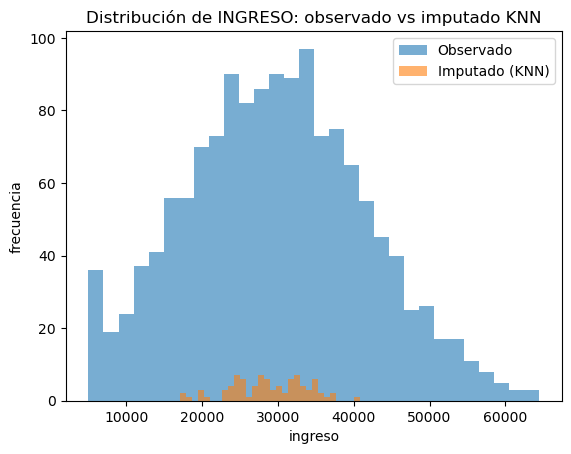

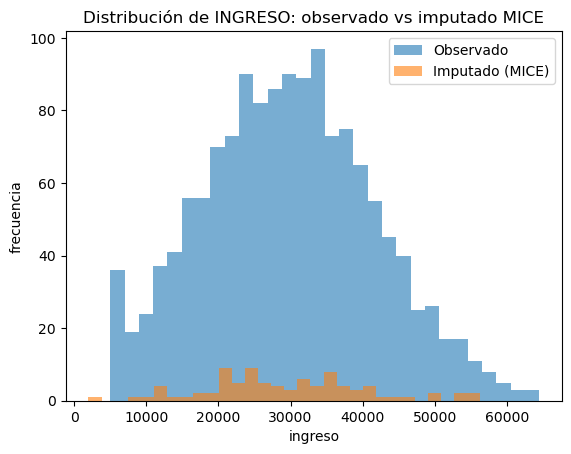

Diferencia promedio |corr(KNN) - corr(base completa)|: 0.0045
Diferencia promedio |corr(MICE) - corr(base completa)|: 0.0061


In [6]:

# === D) Evaluación: distribución antes vs. después ===
# Comparar distribución de INGRESO observado vs imputado (KNN y MICE)
obs_ingreso = df.loc[~df["ingreso"].isna(), "ingreso"]

imp_knn_ingreso = df_knn.loc[df["ingreso"].isna(), "ingreso"]
imp_mice_ingreso = df_mice.loc[df["ingreso"].isna(), "ingreso"]

# 1) Observado vs Imputado (KNN)
plt.figure()
plt.hist(obs_ingreso, bins=30, alpha=0.6, label="Observado")
plt.hist(imp_knn_ingreso, bins=30, alpha=0.6, label="Imputado (KNN)")
plt.title("Distribución de INGRESO: observado vs imputado KNN")
plt.xlabel("ingreso"); plt.ylabel("frecuencia")
plt.legend()
plt.show()

# 2) Observado vs Imputado (MICE)
plt.figure()
plt.hist(obs_ingreso, bins=30, alpha=0.6, label="Observado")
plt.hist(imp_mice_ingreso, bins=30, alpha=0.6, label="Imputado (MICE)")
plt.title("Distribución de INGRESO: observado vs imputado MICE")
plt.xlabel("ingreso"); plt.ylabel("frecuencia")
plt.legend()
plt.show()

# === E) Correlaciones: ¿cambia la estructura? ===
def corr_matrix(df_in, cols):
    return df_in[cols].corr(numeric_only=True)

base_complete = df[num_cols].dropna()
corr_base = corr_matrix(base_complete, num_cols) if len(base_complete) else pd.DataFrame()

corr_knn = corr_matrix(df_knn, num_cols)
corr_mice = corr_matrix(df_mice, num_cols)

# Métricas simples de diferencia (si hay base completa)
if not corr_base.empty:
    diff_knn = (corr_knn - corr_base).abs().values.mean()
    diff_mice = (corr_mice - corr_base).abs().values.mean()
    print(f"Diferencia promedio |corr(KNN) - corr(base completa)|: {diff_knn:.4f}")
    print(f"Diferencia promedio |corr(MICE) - corr(base completa)|: {diff_mice:.4f}")
else:
    print("No hay matriz base completa (sin NA) para comparar correlaciones.")



## 3) Ejercicios <a id="sec-3"></a>


### Ejercicio 1 — Imputación condicional por grupos
**Tarea:** Implementa una función `impute_by_group(df, col, group_col, agg="median")` que reemplace los nulos de `col` con el estadístico por grupo (`median` o `mean`). Aplícala a **`ingreso` por `educacion`** y a **`presion` por grupos de edad**.

*Sugerencia:* usa `groupby(...).transform(...)` y `fillna(...)`.



### Ejercicio 2 — K vecinos vs. distribución
**Tarea:** Aplica **KNNImputer** con `n_neighbors=3` y con `n_neighbors=7`.  
Compara la **media** y **desviación estándar** de `ingreso` imputado (solo las filas originalmente nulas) contra el `ingreso` observado. ¿Cuál K se acerca más?



### Ejercicio 3 — (Mini-MICE) Variabilidad por imputación
**Tarea:** Ejecuta **IterativeImputer** 5 veces con distintos `random_state` y calcula la **variabilidad** (desvío estándar) de la media imputada de `ingreso`.  
¿Qué te dice esto sobre la **incertidumbre** de la imputación múltiple?

